In [5]:
!pip install diffusers transformers accelerate torch torchvision


In [6]:
!pip install tqdm

In [20]:
!pip install torchmetrics torchvision torch-fidelity


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [7]:
from google.colab import files
import zipfile
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from diffusers import DDPMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from diffusers import DDPMPipeline, DDIMScheduler


In [3]:
dataset_zip_path = "/content/balanced_labeled_photos.zip"
unzip_dir = "balanced_labeled_photos"
with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

In [8]:
EPOCHS = 10
BATCH_SIZE = 16
IMAGE_SIZE = 32
NUM_CLASSES = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
DATASET_PATH = "balanced_labeled_photos"

# 1. DATASET: load only a smaller subset of images per class for faster testing
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)
indices_per_class = {i: [] for i in range(NUM_CLASSES)}

sample_size_per_class = 5000

for idx, (_, label) in enumerate(dataset.samples):
    if len(indices_per_class[label]) < sample_size_per_class:
        indices_per_class[label].append(idx)
    if all(len(v) >= sample_size_per_class for v in indices_per_class.values()):
        break

selected_indices = [idx for indices in indices_per_class.values() for idx in indices]
subset = Subset(dataset, selected_indices)
dataloader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)

In [10]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64, num_classes=5, embed_dim=128):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        self.time_embed = nn.Linear(1, embed_dim)
        self.combine = nn.Linear(embed_dim * 2, base_channels * 2)

        self.inc = self.conv_block(in_channels, base_channels)
        self.down1 = self.conv_block(base_channels, base_channels * 2)
        self.down2 = self.conv_block(base_channels * 2, base_channels * 4)
        self.up1 = self.conv_block(base_channels * 4, base_channels * 2)
        self.up2 = self.conv_block(base_channels * 2, base_channels)
        self.outc = nn.Conv2d(base_channels, out_channels, 1)

    def conv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, t, y):
        t = t.float().unsqueeze(1) / 1000
        t_embed = self.time_embed(t)
        y_embed = self.label_emb(y)
        cond = self.combine(torch.cat([t_embed, y_embed], dim=1)).view(-1, 128, 1, 1)  # 🔧 match x2

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x2 = x2 + cond  # ✅ match channel size before down2
        x3 = self.down2(x2)
        x = self.up1(x3) + x2
        x = self.up2(x) + x1
        return torch.tanh(self.outc(x))

In [11]:
model = UNet().to(DEVICE)
scheduler = DDIMScheduler(num_train_timesteps=1000)
optimizer = Adam(model.parameters(), lr=1e-4)

In [12]:
scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = Adam(model.parameters(), lr=1e-4)

# TRAINING LOOP
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    total_batches = 0

    for batch_idx, (images, labels) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}")):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        noise = torch.randn_like(images)
        timesteps = torch.randint(0, scheduler.num_train_timesteps, (images.size(0),), device=DEVICE).long()

        noisy_images = scheduler.add_noise(images, noise, timesteps)
        noise_pred = model(noisy_images, timesteps, labels)

        loss = F.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total_batches += 1

    avg_loss = epoch_loss / total_batches
    print(f"Epoch {epoch+1}/{EPOCHS} - avg loss: {avg_loss:.4f}")

Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
Epoch 1: 100%|██████████| 313/313 [00:16<00:00, 19.25it/s]


Epoch 1/10 - avg loss: 0.3935


Epoch 2: 100%|██████████| 313/313 [00:13<00:00, 23.69it/s]


Epoch 2/10 - avg loss: 0.2267


Epoch 3: 100%|██████████| 313/313 [00:12<00:00, 25.50it/s]


...

Epoch 8/10 - avg loss: 0.1931


Epoch 9: 100%|██████████| 313/313 [00:13<00:00, 22.46it/s]


Epoch 9/10 - avg loss: 0.1920


Epoch 10: 100%|██████████| 313/313 [00:12<00:00, 25.91it/s]

Epoch 10/10 - avg loss: 0.1924


## Evaluation

In [13]:
model.eval()
scheduler.set_timesteps(50)
samples = {}

with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        x = torch.randn(5, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        y = torch.full((5,), class_idx, device=DEVICE, dtype=torch.long)  # ✅ shape [5]
        for t in scheduler.timesteps:
            timesteps = torch.full((5,), t, device=DEVICE, dtype=torch.long)  # ✅ shape [5]
            noise_pred = model(x, timesteps, y)
            x = scheduler.step(noise_pred, t, x).prev_sample
        samples[class_idx] = x.clamp(-1, 1).cpu()


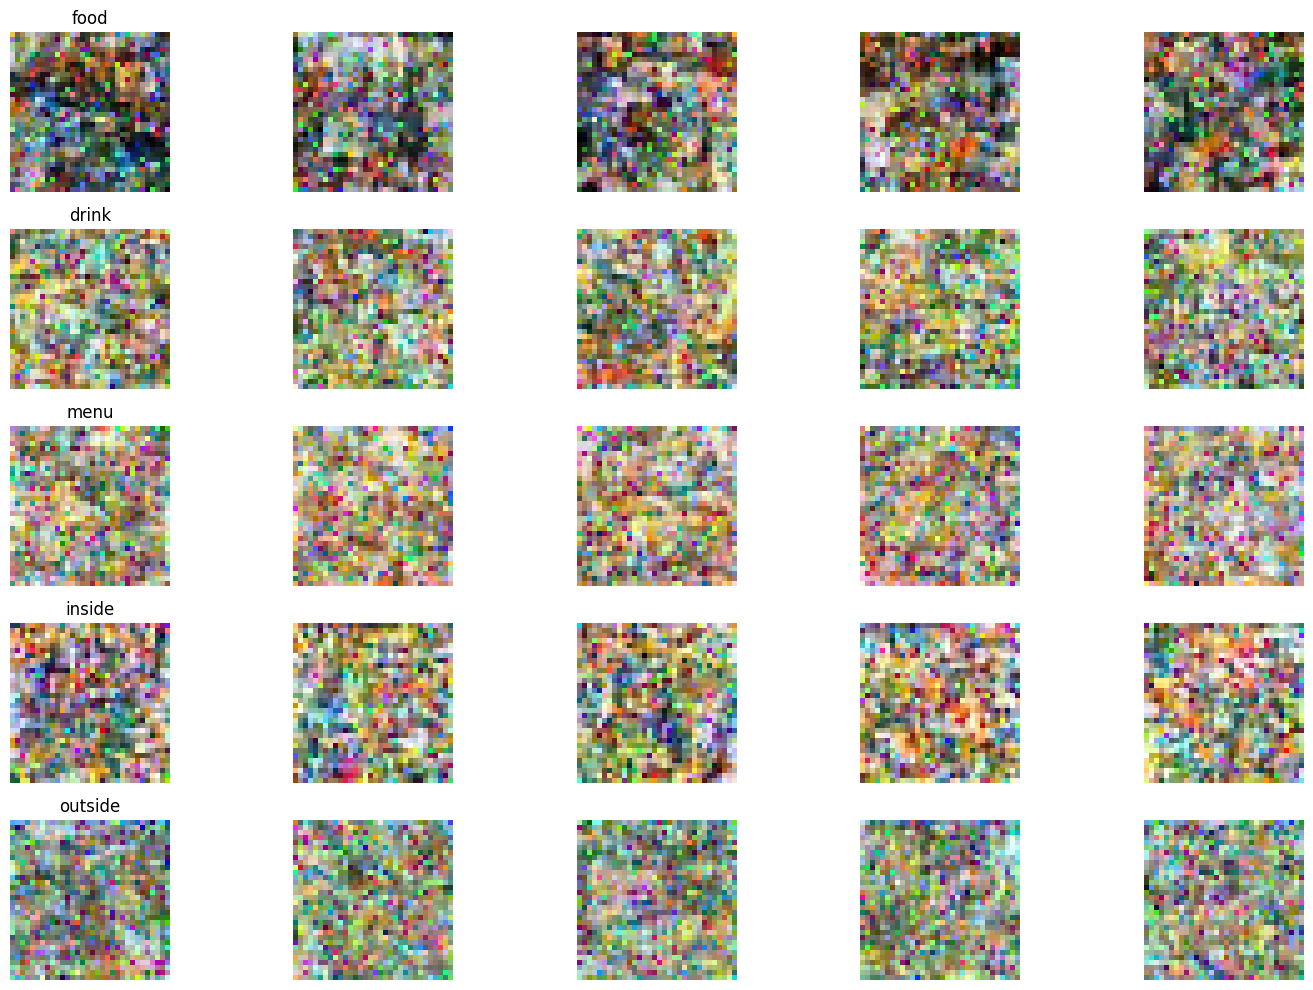

In [14]:
class_names = ['food', 'drink', 'menu', 'inside', 'outside']  # manually set class labels
fig, axes = plt.subplots(len(samples), 5, figsize=(15, 10))

for row, (class_idx, images) in enumerate(samples.items()):
    for col in range(5):
        img = (images[col] * 0.5 + 0.5).permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(class_names[class_idx], fontsize=12)  # ✅ named label

plt.tight_layout()
plt.show()


In [15]:
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
import torch

In [16]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((299, 299)),  # required for InceptionV3
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

real_dataset = ImageFolder("balanced_labeled_photos", transform=transform)
real_loader = DataLoader(real_dataset, batch_size=32, shuffle=True)

# Collect one batch of real images (for demo)
real_images, _ = next(iter(real_loader))
real_images = real_images[:32].to("cuda" if torch.cuda.is_available() else "cpu")


In [17]:
gen_images = torch.cat([imgs for imgs in samples.values()], dim=0)  # shape: [N, 3, 64, 64]
gen_images = torch.nn.functional.interpolate(gen_images, size=(299, 299))  # upscale to 299x299

In [26]:
device = torch.device("cpu") # Calculate metrics on CPU to avoid CUDA device mismatch

# Inception Score
is_metric = InceptionScore(splits=1, normalize=True).to(device)
# Ensure input is on the correct device and data type
is_metric.update(gen_images.to(device).float())
inception_score = is_metric.compute()

# FID
fid_metric = FrechetInceptionDistance(normalize=True).to(device)
# Ensure inputs are on the correct device and data type
fid_metric.update(real_images.to(device).float(), real=True)
fid_metric.update(gen_images.to(device).float(), real=False)
fid_score = fid_metric.compute()

# Access the mean inception score from the tuple before calling .item()
print(f"Inception Score: {inception_score[0].item():.4f}")
print(f"FID Score: {fid_score.item():.4f}")

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torchmetrics/image/inception.py:177: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  return kl.mean(), kl.std()


Inception Score: 1.0056
FID Score: 528.6810


## Model Tuning

In [23]:
from torch.optim import Adam
import torch.nn.functional as F
from tqdm import tqdm


# Tuning config
EPOCHS_PER_ROUND = 10
tuning_configs = [
    {"lr": 1e-4, "desc": "Tuning Round 1 - LR=1e-4"},
    {"lr": 5e-5, "desc": "Tuning Round 2 - LR=5e-5"}
]

# Perform tuning
for config in tuning_configs:
    optimizer = Adam(model.parameters(), lr=config["lr"])
    model.train()
    print(f"\n{config['desc']}")

    for epoch in range(EPOCHS_PER_ROUND):
        epoch_loss = 0.0
        total_batches = 0

        for batch_idx, (images, labels) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}")):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            noise = torch.randn_like(images)
            timesteps = torch.randint(0, scheduler.num_train_timesteps, (images.size(0),), device=DEVICE).long()
            noisy_images = scheduler.add_noise(images, noise, timesteps)

            noise_pred = model(noisy_images, timesteps, labels)
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            total_batches += 1

        avg_loss = epoch_loss / total_batches
        print(f" {config['desc']} - avg loss: {avg_loss:.4f}")



Tuning Round 1 - LR=1e-4


Epoch 1: 100%|██████████| 313/313 [00:12<00:00, 25.96it/s]


 Tuning Round 1 - LR=1e-4 - avg loss: 0.1920


Epoch 2: 100%|██████████| 313/313 [00:11<00:00, 26.13it/s]


 Tuning Round 1 - LR=1e-4 - avg loss: 0.1891


...

 Tuning Round 2 - LR=5e-5 - avg loss: 0.1842


Epoch 9: 100%|██████████| 313/313 [00:11<00:00, 26.11it/s]


 Tuning Round 2 - LR=5e-5 - avg loss: 0.1855


Epoch 10: 100%|██████████| 313/313 [00:11<00:00, 26.22it/s]

 Tuning Round 2 - LR=5e-5 - avg loss: 0.1854


In [30]:
import torch
from torchvision import datasets, transforms
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import DataLoader

# Generate 10 synthetic images (2 per class) after tuning
model.eval()
scheduler.set_timesteps(50)
samples = []

# Use the original training device for sampling
sampling_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(sampling_device) # Ensure model is on sampling device

with torch.no_grad():
    for class_idx in range(5):
        # Generate noise on the sampling device
        x = torch.randn(2, 3, 32, 32).to(sampling_device)
        y = torch.tensor([class_idx] * 2).to(sampling_device)
        for t in scheduler.timesteps:
            timesteps = torch.full((2,), t, device=sampling_device, dtype=torch.long)
            # The custom UNet model expects x, t, and y as inputs
            noise_pred = model(x, timesteps, y)
            x = scheduler.step(noise_pred, t, x).prev_sample
        samples.append(x.clamp(-1, 1).cpu()) # Move generated images to CPU

gen_images = torch.cat(samples, dim=0)  # shape: [10, 3, 32, 32]
gen_images = torch.nn.functional.interpolate(gen_images, size=(299, 299))

# Set device to CPU for metric calculations
metric_device = torch.device("cpu")

# Ensure gen_images is on the CPU and float type for metrics
gen_images = gen_images.to(metric_device).float()

# Get real images
transform_299 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
real_dataset = datasets.ImageFolder("balanced_labeled_photos", transform=transform_299)
real_loader = DataLoader(real_dataset, batch_size=16, shuffle=True, num_workers=0)
real_images, _ = next(iter(real_loader))
# Ensure real_images is on the CPU and float type for metrics
real_images = real_images[:10].to(metric_device).float()

# Evaluate using torchmetrics on CPU
is_metric = InceptionScore(splits=1, normalize=True).to(metric_device)
fid_metric = FrechetInceptionDistance(normalize=True).to(metric_device)

is_metric.update(gen_images)
fid_metric.update(real_images, real=True)
fid_metric.update(gen_images, real=False)

# Compute scores and access the mean inception score from the tuple
inception_score_tuple = is_metric.compute()
inception_score = inception_score_tuple[0].item() # Access the mean score

fid_score = fid_metric.compute().item()

print(f"Inception Score: {inception_score:.4f}")
print(f"FID Score: {fid_score:.4f}")

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torchmetrics/image/inception.py:177: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  return kl.mean(), kl.std()


Inception Score: 1.0339
FID Score: 531.3998
